# GENCYS 2.0 - Exercise No. 2

# Entanglement and Bell States

### Qiskit 2.5.2 - Google Colab Notebook

In this exercise, we will create one of the most important two-qubit states in quantum computing: a **Bell state**.

We will:

- create a circuit with two qubits
- use a Hadamard (`H`) gate and a controlled-NOT (`CX`) gate
- inspect the statevector before measurement
- measure the circuit about 1000 times
- distinguish entangled correlation from two independent random bits
- modify the circuit to create a different Bell state

> **Note:** Qiskit Aer is a classical simulator. It reproduces the ideal measurement statistics of a quantum circuit, but this notebook does not run on physical quantum hardware.


## Two Qubits

Two classical bits can store one of four values: `00`, `01`, `10`, or `11`. Two qubits have four computational basis states:

$$
|00\rangle,\quad |01\rangle,\quad |10\rangle,\quad |11\rangle
$$

A general two-qubit state can be written as:

$$
|\psi\rangle=a|00\rangle+b|01\rangle+c|10\rangle+d|11\rangle
$$

The squared magnitudes $|a|^2$, $|b|^2$, $|c|^2$, and $|d|^2$ are the four measurement probabilities, and together they add up to 1.


## What Is a Bell State?

We begin with both qubits in $|0\rangle$, so the combined state is $|00\rangle$. First, a Hadamard gate puts qubit 0 into an equal superposition. Then a `CX` gate uses qubit 0 as the **control** and qubit 1 as the **target**. The target flips only when the control is 1.

The final state is:

$$
|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt{2}}
$$

This is an **entangled state**. It cannot be described as one independent state for qubit 0 multiplied by another independent state for qubit 1.

### Circuit

```text
q0: |0> --- H --- ● --- Measure
                  |
q1: |0> -------- X --- Measure
```


## Install Qiskit

Run this cell first in Google Colab. It installs Qiskit 2.5.2, Qiskit Aer for simulation, and `pylatexenc` for circuit drawing.


In [1]:
!pip install -q "qiskit==2.5.2" "qiskit-aer~=0.17" pylatexenc ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.0 MB/s eta 0:00:00


## Import Qiskit and Check the Version


In [2]:
import qiskit
import qiskit_aer

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2


## Build the Bell-State Circuit

The circuit uses two steps:

1. `H` creates a superposition on qubit 0.
2. `CX` links qubit 1 to qubit 0. Qubit 0 is the control and qubit 1 is the target.

We leave out measurement for now so that we can inspect the quantum state first.


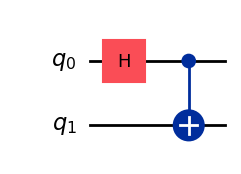

In [3]:
bell_circuit = QuantumCircuit(2)

# Put qubit 0 into superposition
bell_circuit.h(0)

# Entangle qubit 0 with qubit 1
bell_circuit.cx(0, 1)

bell_circuit.draw("mpl")

## Follow the State Through the Gates

Using the usual mathematical ordering with qubit 0 written first, the Hadamard produces:

$$
|00\rangle\xrightarrow{H}\frac{|00\rangle+|10\rangle}{\sqrt{2}}
$$

The `CX` leaves the first branch unchanged and flips the target in the second branch:

$$
|00\rangle\rightarrow|00\rangle,\qquad |10\rangle\rightarrow|11\rangle
$$

Therefore the completed circuit prepares $(|00\rangle+|11\rangle)/\sqrt{2}$.


## Inspect the Statevector

A statevector shows the amplitudes before measurement collapses the state.


In [4]:
bell_state = Statevector.from_instruction(bell_circuit)

print("Statevector:")
print(bell_state)

print("\nProbabilities:")
print(bell_state.probabilities_dict())

Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Probabilities:
{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


### Understanding the Statevector

For two qubits, the four amplitudes correspond to `|00>`, `|01>`, `|10>`, and `|11>`. Qiskit displays multi-qubit bit strings as `q1 q0`, with the highest-numbered qubit on the left. For this symmetric state, the nonzero labels are still `00` and `11`.

The statevector should be approximately:

```text
[0.707+0.j, 0.+0.j, 0.+0.j, 0.707+0.j]
```

The amplitudes of $|01\rangle$ and $|10\rangle$ are zero. Squaring the other two amplitudes gives:

$$
P(00)=\frac{1}{2},\qquad P(11)=\frac{1}{2}
$$


## Random Individually, Correlated Together

If we look at either qubit by itself, it has a 50% chance of being 0 and a 50% chance of being 1. However, the answers are **not independent**. When both are measured in this basis, they always agree in the ideal circuit:

```text
00 or 11
```

They should not produce `01` or `10`. Two independent fair random bits would produce all four outcomes with about 25% probability each.

> Entanglement creates correlations, but it cannot send a controllable message faster than light. Each local result is still random.


## Add Measurements

We copy the state-preparation circuit and add a measurement for each qubit. `measure_all()` automatically creates the classical bits that store the results.


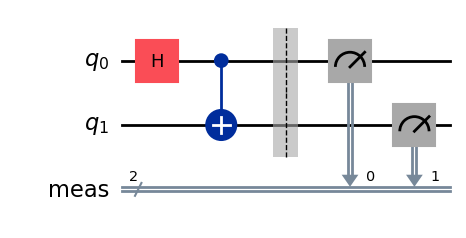

In [5]:
measured_bell_circuit = bell_circuit.copy()
measured_bell_circuit.measure_all()

measured_bell_circuit.draw("mpl")

## Simulate 1000 Measurements

Each execution is called a **shot**. We use many shots to reveal the joint probability distribution.


Measurement counts: {'00': 497, '11': 503}


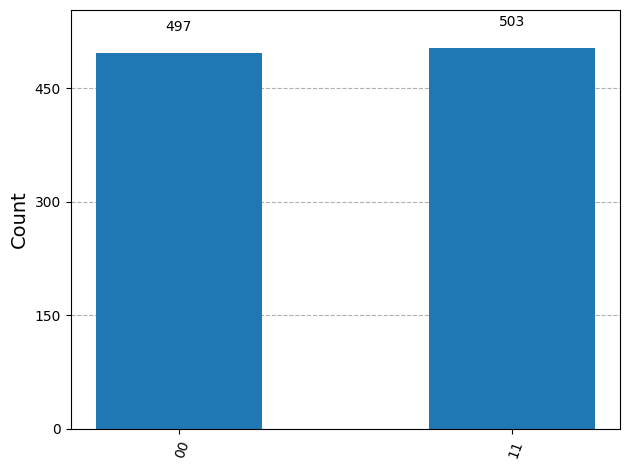

In [6]:
simulator = AerSimulator()

compiled_bell_circuit = transpile(measured_bell_circuit, simulator)
job = simulator.run(compiled_bell_circuit, shots=1000)
result = job.result()

bell_counts = result.get_counts(compiled_bell_circuit)

print("Measurement counts:", bell_counts)

plot_histogram(bell_counts)

### What should happen?

You should get something approximately like:

```text
{'00': 493, '11': 507}
```

The exact counts will usually change and do not need to be exactly 500 and 500. The important observation is:

```text
about 50% -> 00
about 50% -> 11
about  0% -> 01 or 10
```

This is a joint distribution: both qubits are random, but their results are correlated.


## Check the Correlation

The next cell calculates how often the two measured bits agree. On the ideal simulator, the correlation rate should be 100%.


In [7]:
total_shots = sum(bell_counts.values())
matching_shots = bell_counts.get("00", 0) + bell_counts.get("11", 0)
nonmatching_shots = bell_counts.get("01", 0) + bell_counts.get("10", 0)
correlation_rate = matching_shots / total_shots

print("Matching results:", matching_shots)
print("Non-matching results:", nonmatching_shots)
print(f"Correlation rate: {correlation_rate:.1%}")

Matching results: 1000
Non-matching results: 0
Correlation rate: 100.0%


## Interactive Bell-State Explorer

Select one of the four Bell states and measure it. Notice that the plus and minus versions have the same computational-basis counts even though their phases differ.

In [8]:
import ipywidgets as widgets
from IPython.display import clear_output, display

bell_picker = widgets.Dropdown(options=["Phi+", "Phi-", "Psi+", "Psi-"], description="State:")
bell_shots = widgets.IntSlider(value=1000, min=100, max=5000, step=100, description="Shots:")
bell_button = widgets.Button(description="Measure", button_style="info")
bell_output = widgets.Output()

def measure_selected_bell_state(_):
    name = bell_picker.value
    circuit = QuantumCircuit(2)
    circuit.h(0)
    circuit.cx(0, 1)
    if name.startswith("Psi"):
        circuit.x(1)
    if name.endswith("-"):
        circuit.z(0)
    circuit.measure_all()
    compiled = transpile(circuit, simulator)
    counts = simulator.run(compiled, shots=bell_shots.value).result().get_counts(compiled)
    with bell_output:
        clear_output(wait=True)
        print(f"|{name}> counts:", counts)
        display(plot_histogram(counts))

bell_button.on_click(measure_selected_bell_state)
display(widgets.VBox([bell_picker, bell_shots, bell_button, bell_output]))


## Compare with Two Independent Qubits

To see why `CX` matters, apply `H` to both qubits without connecting them. Each qubit is now a fair random bit, independent of the other one.


Independent-qubit counts: {'01': 235, '11': 252, '10': 263, '00': 250}


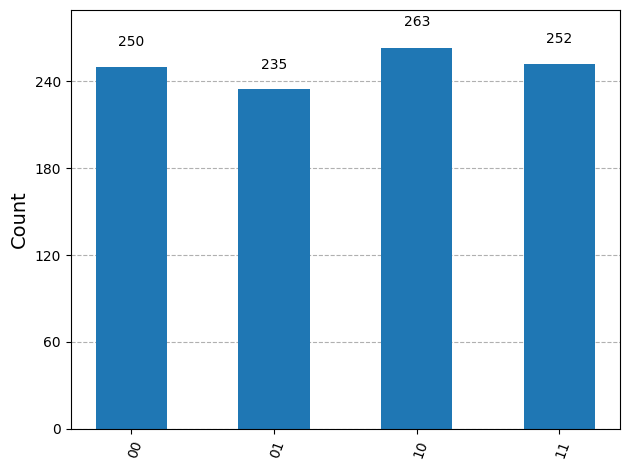

In [9]:
independent_circuit = QuantumCircuit(2)
independent_circuit.h([0, 1])
independent_circuit.measure_all()

compiled_independent = transpile(independent_circuit, simulator)
independent_result = simulator.run(compiled_independent, shots=1000).result()
independent_counts = independent_result.get_counts(compiled_independent)

print("Independent-qubit counts:", independent_counts)

plot_histogram(independent_counts)

You should now see all four bit strings—`00`, `01`, `10`, and `11`—with roughly 25% of the shots each.

- `H` on both qubits creates **independent randomness**.
- `H` followed by `CX` creates an **entangled correlation**.


## Exercise 1: Create an Anti-Correlated Bell State

The Bell state we built produces matching results. Your task is to create:

$$
|\Psi^+\rangle=\frac{|01\rangle+|10\rangle}{\sqrt{2}}
$$

Requirements:

1. Start with a two-qubit circuit.
2. Apply `H` to qubit 0.
3. Apply `CX` with qubit 0 as control and qubit 1 as target.
4. Add one `X` gate to either qubit **after** the `CX`.
5. Measure both qubits and simulate 1000 shots.
6. Display the counts and a histogram.

Do not copy `bell_counts`; run your new circuit.


In [ ]:
# Write your code here.
# TODO: Build the |Psi+> Bell-state circuit here.
psi_plus_circuit = QuantumCircuit(2)

# TODO: Add H, CX, and one X gate.

# TODO: Measure both qubits.

# TODO: Transpile and run 1000 shots with the simulator.

# TODO: Print the counts and display a histogram.


### Expected behavior

After completing the TODOs, the results should be approximately:

```text
about 50% -> 01
about 50% -> 10
about  0% -> 00 or 11
```

The exact counts can vary, but the two bits should always be opposite on the ideal simulator.

**Hint:** An `X` gate changes $|0\rangle$ to $|1\rangle$ and $|1\rangle$ to $|0\rangle$. Applying it to one member of $|\Phi^+\rangle$ changes matching branches into opposite branches.


## Exercise 2: Try It Yourself

### Easy

- Change the number of shots to 100, 1000, and 10,000. Compare the percentages.
- Remove the `CX` gate and explain the new measurement results.

### Medium

- Write a function that returns `True` only if all Bell-state measurements are correlated.
- Create $|\Phi^-\rangle=(|00\rangle-|11\rangle)/\sqrt{2}$ by adding a `Z` gate. Its computational-basis counts match $|\Phi^+\rangle$; think about why another measurement basis is needed to reveal the minus sign.

### Extra

Research the four Bell states and build a function that creates any one of them from a name supplied by the user.


In [ ]:
# Write your code here.


## What We Learned

The core Bell-state circuit is:

```text
q0: |0> --- H --- ● --- M
                  |
q1: |0> -------- X --- M
```

It introduces several important ideas:

1. **Two-qubit basis states** - two qubits have four computational basis states.
2. **Hadamard gate** - creates a superposition on the control qubit.
3. **Controlled-NOT gate** - changes the target according to the control.
4. **Entanglement** - the complete state cannot be separated into two independent single-qubit states.
5. **Joint measurement** - the ideal Bell state produces `00` or `11`, not four independent outcomes.
6. **Correlation** - each local result is random, while the pair follows a definite relationship.

### Simulator vs quantum hardware

This notebook uses **Qiskit Aer**. The ideal simulator should produce only `00` and `11` for $|\Phi^+\rangle$.

On real quantum hardware, gate errors, decoherence, and measurement errors can produce a small number of unexpected `01` or `10` results. Comparing ideal and hardware results is one way to study quantum noise.
